저장 완료: viz1_domain_pos_neg.png


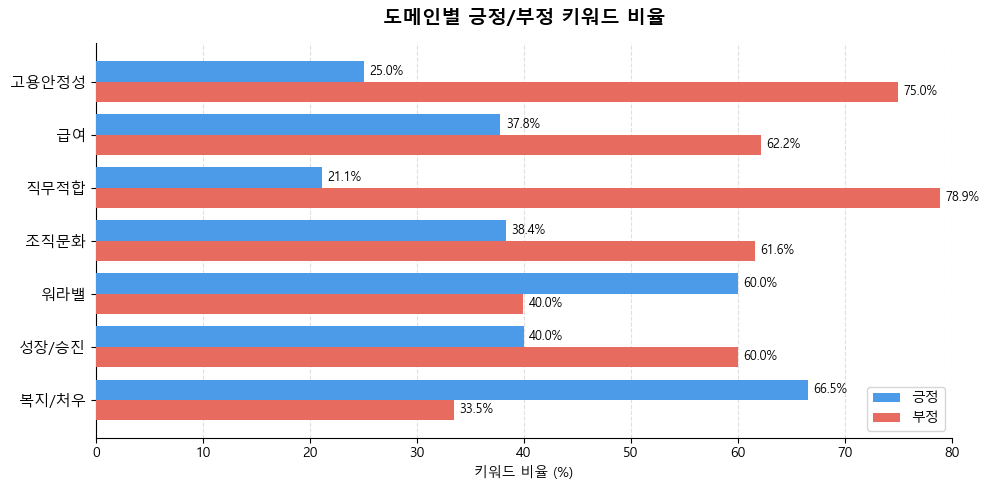

저장 완료: viz2_grade_boxplot.png


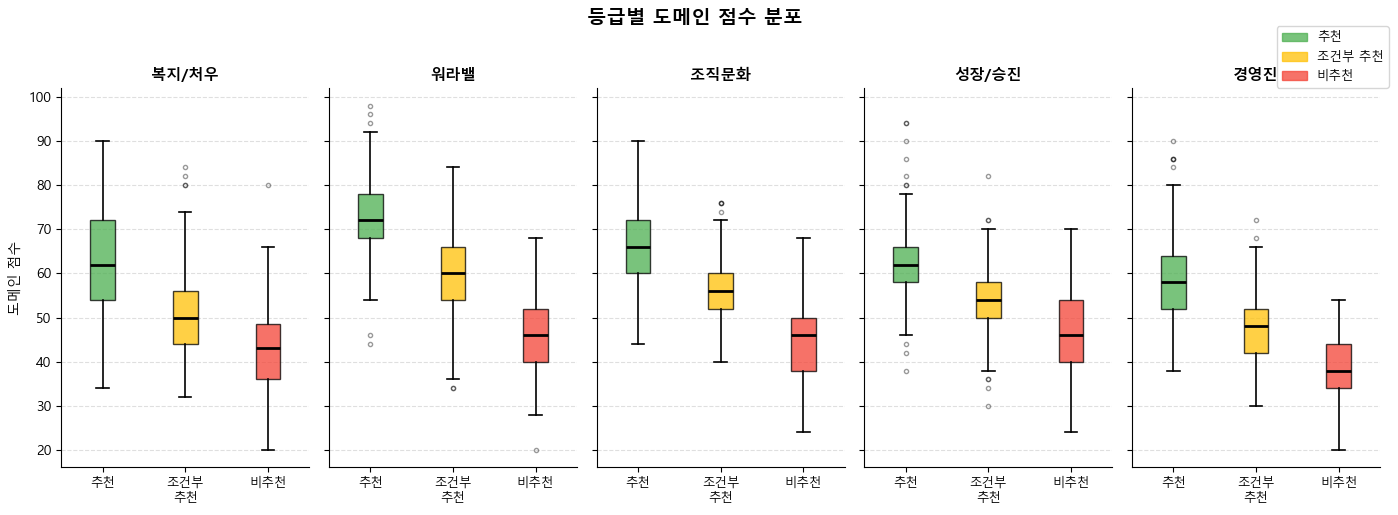

저장 완료: viz3_radar_chart.png


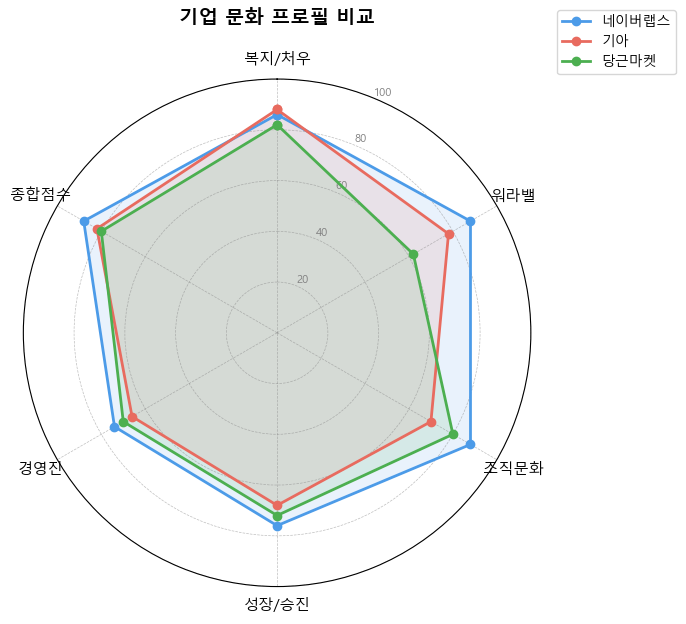

등급별 점수 범위:
                min   max
review_grade            
비추천           40.1  54.7
조건부 추천        55.0  82.8
추천            75.2  90.0
저장 완료: viz4_score_histogram.png


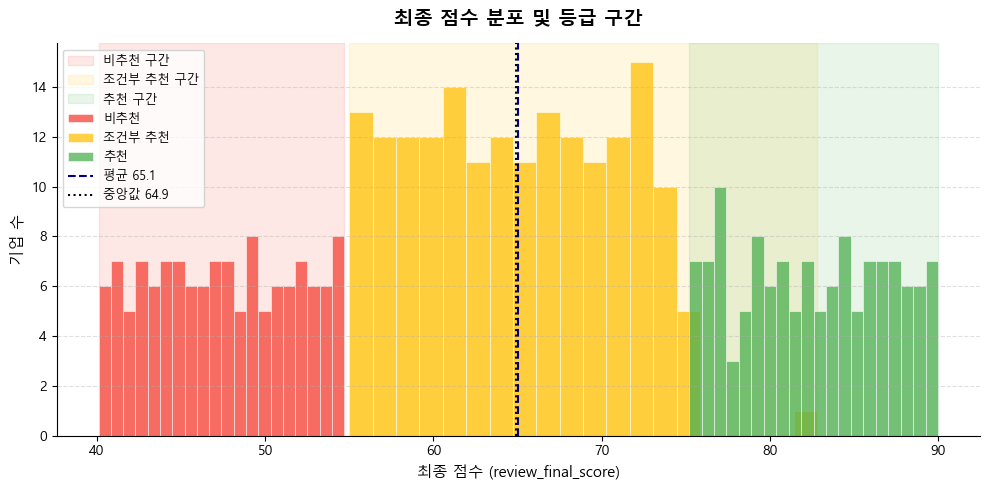

In [2]:
"""
잡플래닛 리뷰 데이터 시각화 코드
대상 파일: review_analysis_table_final__1_.xlsx

4가지 시각화:
1. 도메인별 긍/부정 키워드 비율 이중 바차트 (EDA)
2. 등급별 도메인 점수 분포 박스플롯 (EDA)
3. 기업 문화 프로필 레이더 차트 (3개 기업 비교) (서비스 화면)
4. 최종 점수 분포 + 등급 구간 히스토그램 (서비스 화면)
"""

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from matplotlib import rcParams

# ── 한글 폰트 설정 ──────────────────────────────────────────────────────────
# macOS: 'AppleGothic', Windows: 'Malgun Gothic', Linux: 'Noto Sans CJK KR'
rcParams['font.family'] = 'Malgun Gothic'
rcParams['axes.unicode_minus'] = False

# ── 데이터 로드 ─────────────────────────────────────────────────────────────
df = pd.read_excel(r"C:\py_temp\중간프로젝트\잡플래닛시각화\review_analysis_table_final.xlsx")

# ── 색상 팔레트 ─────────────────────────────────────────────────────────────
POS_COLOR  = '#4C9BE8'   # 긍정 파랑
NEG_COLOR  = '#E86B5F'   # 부정 빨강
GRADE_COLORS = {
    '추천':      '#4CAF50',
    '조건부 추천': '#FFC107',
    '비추천':    '#F44336',
}


# ═══════════════════════════════════════════════════════════════════════════
# [1] 도메인별 긍/부정 키워드 비율 이중 바차트
# ═══════════════════════════════════════════════════════════════════════════
def plot_domain_pos_neg_bar(df: pd.DataFrame, save_path: str = None):
    """
    각 도메인(복지, 성장, 워라밸, 조직문화, 직무적합, 급여, 안정성)에 대해
    긍정/부정 키워드 합산 건수 비율을 이중 수평 바차트로 그린다.
    """
    domains = {
        '복지/처우':   ('welfare_pos_count',  'welfare_neg_count'),
        '성장/승진':   ('growth_pos_count',   'growth_neg_count'),
        '워라밸':      ('worklife_pos_count', 'worklife_neg_count'),
        '조직문화':    ('culture_pos_count',  'culture_neg_count'),
        '직무적합':    ('jobfit_pos_count',   'jobfit_neg_count'),
        '급여':        ('salary_pos_count',   'salary_neg_count'),
        '고용안정성':  ('stability_pos_count','stability_neg_count'),
    }

    labels, pos_vals, neg_vals = [], [], []
    for name, (pc, nc) in domains.items():
        total = df[pc].sum() + df[nc].sum()
        if total == 0:
            continue
        labels.append(name)
        pos_vals.append(df[pc].sum() / total * 100)
        neg_vals.append(df[nc].sum() / total * 100)

    fig, ax = plt.subplots(figsize=(10, 5))
    y = np.arange(len(labels))
    bar_h = 0.38

    bars_pos = ax.barh(y + bar_h / 2, pos_vals, bar_h,
                       color=POS_COLOR, label='긍정', zorder=3)
    bars_neg = ax.barh(y - bar_h / 2, neg_vals, bar_h,
                       color=NEG_COLOR, label='부정', zorder=3)

    # 값 레이블
    for bar in bars_pos:
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                f'{bar.get_width():.1f}%', va='center', fontsize=9)
    for bar in bars_neg:
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                f'{bar.get_width():.1f}%', va='center', fontsize=9)

    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=11)
    ax.set_xlabel('키워드 비율 (%)', fontsize=10)
    ax.set_title('도메인별 긍정/부정 키워드 비율', fontsize=14, fontweight='bold', pad=14)
    ax.legend(loc='lower right', fontsize=10)
    ax.set_xlim(0, 80)
    ax.grid(axis='x', linestyle='--', alpha=0.4, zorder=0)
    ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"저장 완료: {save_path}")
    plt.show()


# ═══════════════════════════════════════════════════════════════════════════
# [2] 등급별 도메인 점수 분포 박스플롯
# ═══════════════════════════════════════════════════════════════════════════
def plot_grade_domain_boxplot(df: pd.DataFrame, save_path: str = None):
    """
    review_grade(추천 / 조건부 추천 / 비추천) × 도메인 점수 박스플롯.
    각 도메인마다 등급 3개의 박스를 나란히 배치한다.
    """
    domain_cols = {
        '복지/처우':  'welfare_score',
        '워라밸':     'worklife_score',
        '조직문화':   'culture_score',
        '성장/승진':  'promotion_score',
        '경영진':     'management_score',
    }
    grade_order = ['추천', '조건부 추천', '비추천']
    grade_order = [g for g in grade_order if g in df['review_grade'].unique()]

    n_domains = len(domain_cols)
    fig, axes = plt.subplots(1, n_domains, figsize=(14, 5), sharey=True)

    for ax, (domain_name, col) in zip(axes, domain_cols.items()):
        data_by_grade = [df.loc[df['review_grade'] == g, col].dropna().values
                         for g in grade_order]

        bp = ax.boxplot(data_by_grade,
                        patch_artist=True,
                        medianprops=dict(color='black', linewidth=2),
                        whiskerprops=dict(linewidth=1.2),
                        capprops=dict(linewidth=1.2),
                        flierprops=dict(marker='o', markersize=3,
                                        alpha=0.4, linestyle='none'))

        for patch, grade in zip(bp['boxes'], grade_order):
            patch.set_facecolor(GRADE_COLORS.get(grade, '#999'))
            patch.set_alpha(0.75)

        ax.set_title(domain_name, fontsize=11, fontweight='bold')
        ax.set_xticks(range(1, len(grade_order) + 1))
        ax.set_xticklabels([g.replace(' ', '\n') for g in grade_order], fontsize=9)
        ax.grid(axis='y', linestyle='--', alpha=0.4)
        ax.spines[['top', 'right']].set_visible(False)

    axes[0].set_ylabel('도메인 점수', fontsize=10)
    fig.suptitle('등급별 도메인 점수 분포', fontsize=14, fontweight='bold', y=1.02)

    # 범례
    patches = [mpatches.Patch(color=GRADE_COLORS[g], label=g, alpha=0.75)
               for g in grade_order]
    fig.legend(handles=patches, loc='upper right',
               bbox_to_anchor=(1.0, 1.0), fontsize=9)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"저장 완료: {save_path}")
    plt.show()


# ═══════════════════════════════════════════════════════════════════════════
# [3] 기업 문화 프로필 레이더 차트 (3개 기업 비교)
# ═══════════════════════════════════════════════════════════════════════════
def plot_radar_chart(df: pd.DataFrame,
                     companies: list,
                     save_path: str = None):
    """
    지정한 기업 3곳의 도메인 점수를 레이더 차트로 비교한다.

    Parameters
    ----------
    companies : list of str
        normalized_company_name 기준 기업명 3개 (예: ['네이버랩스', '기아', '당근마켓'])
    """
    categories = {
        '복지/처우':  'welfare_score',
        '워라밸':     'worklife_score',
        '조직문화':   'culture_score',
        '성장/승진':  'promotion_score',
        '경영진':     'management_score',
        '종합점수':   'overall_score',
    }
    cat_labels = list(categories.keys())
    N = len(cat_labels)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]   # 닫기

    RADAR_COLORS = ['#4C9BE8', '#E86B5F', '#4CAF50']
    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

    for i, company in enumerate(companies[:3]):
        row = df[df['normalized_company_name'] == company]
        if row.empty:
            print(f"⚠️  '{company}' 를 찾을 수 없습니다.")
            continue
        values = [row[col].values[0] for col in categories.values()]
        values += values[:1]   # 닫기

        color = RADAR_COLORS[i]
        ax.plot(angles, values, 'o-', linewidth=2, color=color, label=company)
        ax.fill(angles, values, alpha=0.12, color=color)

    # 축 설정
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.degrees(angles[:-1]), cat_labels, fontsize=11)
    ax.set_ylim(0, 100)
    ax.set_yticks([20, 40, 60, 80, 100])
    ax.set_yticklabels(['20', '40', '60', '80', '100'], fontsize=8, color='grey')
    ax.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.5)

    ax.set_title('기업 문화 프로필 비교', fontsize=14, fontweight='bold',
                 pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.15), fontsize=10)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"저장 완료: {save_path}")
    plt.show()


# ═══════════════════════════════════════════════════════════════════════════
# [4] 최종 점수 분포 + 등급 구간 히스토그램
# ═══════════════════════════════════════════════════════════════════════════
def plot_final_score_histogram(df: pd.DataFrame, save_path: str = None):
    """
    review_final_score 의 히스토그램 위에 등급 구간 색깔 배경을 오버레이한다.
    실제 등급 컷오프는 데이터에서 자동 추정한다.
    """
    scores = df['review_final_score'].dropna()

    # 등급별 score 범위 자동 추정
    grade_ranges = (
        df.groupby('review_grade')['review_final_score']
        .agg(['min', 'max'])
    )
    print("등급별 점수 범위:\n", grade_ranges)

    fig, ax = plt.subplots(figsize=(10, 5))

    # 등급 배경 음영
    zone_alpha = 0.12
    grade_zone_map = [
        ('비추천',      '#F44336'),
        ('조건부 추천', '#FFC107'),
        ('추천',        '#4CAF50'),
    ]
    for grade, color in grade_zone_map:
        if grade in grade_ranges.index:
            lo = grade_ranges.loc[grade, 'min']
            hi = grade_ranges.loc[grade, 'max']
            ax.axvspan(lo, hi, alpha=zone_alpha, color=color, label=f'{grade} 구간')

    # 히스토그램 (등급별 색상)
    grade_order = ['비추천', '조건부 추천', '추천']
    for grade, color in zip(grade_order, ['#F44336', '#FFC107', '#4CAF50']):
        subset = df.loc[df['review_grade'] == grade, 'review_final_score'].dropna()
        ax.hist(subset, bins=20, color=color, alpha=0.75,
                edgecolor='white', linewidth=0.5, label=grade)

    # 중앙값·평균 선
    ax.axvline(scores.mean(),  color='navy',  linestyle='--',
               linewidth=1.5, label=f'평균 {scores.mean():.1f}')
    ax.axvline(scores.median(), color='black', linestyle=':',
               linewidth=1.5, label=f'중앙값 {scores.median():.1f}')

    ax.set_xlabel('최종 점수 (review_final_score)', fontsize=11)
    ax.set_ylabel('기업 수', fontsize=11)
    ax.set_title('최종 점수 분포 및 등급 구간', fontsize=14,
                 fontweight='bold', pad=14)
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"저장 완료: {save_path}")
    plt.show()


# ═══════════════════════════════════════════════════════════════════════════
# 실행 예시
# ═══════════════════════════════════════════════════════════════════════════
if __name__ == '__main__':

    # [1] 도메인별 긍/부정 키워드 비율 이중 바차트
    plot_domain_pos_neg_bar(df, save_path='viz1_domain_pos_neg.png')

    # [2] 등급별 도메인 점수 분포 박스플롯
    plot_grade_domain_boxplot(df, save_path='viz2_grade_boxplot.png')

    # [3] 레이더 차트 – 비교할 3개 기업명을 직접 지정
    target_companies = ['네이버랩스', '기아', '당근마켓']   # ← 원하는 기업으로 변경
    plot_radar_chart(df, companies=target_companies,
                     save_path='viz3_radar_chart.png')

    # [4] 최종 점수 분포 히스토그램
    plot_final_score_histogram(df, save_path='viz4_score_histogram.png')
